In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pickle
import numpy as np
from esp_ppq.api import espdl_quantize_onnx, QuantizationSettingFactory
from esp_ppq.core import TargetPlatform
import onnx


    ___________ ____        ____  ____  ____
   / ____/ ___// __ \      / __ \/ __ \/ __ \
  / __/  \__ \/ /_/ /_____/ /_/ / /_/ / / / /
 / /___ ___/ / ____/_____/ ____/ ____/ /_/ /
/_____//____/_/         /_/   /_/    \___\_\




In [3]:
class CalibrationDataset(Dataset):
    def __init__(self, X):
        self.X = torch.FloatTensor(X).unsqueeze(1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx]
    
with open('../dataset/cal.pkl', 'rb') as f:
    X_cal, _ = pickle.load(f)

cal_dataset = CalibrationDataset(X_cal)
cal_loader = DataLoader(cal_dataset, batch_size=32, shuffle=False)

In [5]:
ONNX_MODEL_PATH = "../training/gesture_model.onnx"
EXPORT_PATH = "../deployment/model/gesture_model_balanced.espdl"
input_shape = [1, 1, 96, 96]

setting = QuantizationSettingFactory.espdl_setting()

# LayerwiseEqualization
setting.equalization = True
setting.equalization_setting.opt_level = 2 # add/sub
setting.equalization_setting.iterations = 10
setting.equalization_setting.value_threshold = 0.5
setting.equalization_setting.including_bias = True
setting.equalization_setting.bias_multiplier = 0.5
setting.equalization_setting.including_act = True
setting.equalization_setting.act_multiplier = 0.5

# Algorithm
setting.quantize_activation_setting.calib_algorithm = 'kl'

graph = espdl_quantize_onnx(
    onnx_import_file=ONNX_MODEL_PATH,
    espdl_export_file=EXPORT_PATH,
    calib_dataloader=cal_loader,
    calib_steps=50,
    input_shape=[input_shape],
    target="esp32s3",
    num_of_bits=8,
    setting=setting,
    device="cpu",
    error_report=True,
    verbose=1
)


[19:48:16] PPQ Layerwise Equalization Pass Running ...  

Equalization Data Collecting.: 17it [00:02,  6.81it/s]                        


1 equalization pair(s) was found, ready to run optimization.


Layerwise Equalization: 100%|██████████| 10/10 [00:00<00:00, 3799.53it/s]


[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]
[node_Conv_224(Type: Conv, Num of Input: 3, Num of Output: 1), node_Conv_218(Type: Conv, Num of Input: 3, Num of Output: 1)]


...

Finished.
[19:48:34] PPQ Quantization Alignment Pass Running ...    Finished.
[19:48:34] PPQ Passive Parameter Quantization Running ... Finished.
--------- Network Snapshot ---------
Num of Op:                    [27]
Num of Quantized Op:          [27]
Num of Variable:              [76]
Num of Quantized Var:         [76]
------- Quantization Snapshot ------
Num of Quant Config:          [104]
ACTIVATED:                    [30]
OVERLAPPED:                   [34]
PASSIVE:                      [38]
FP32:                         [2]
Network Quantization Finished.


Analysing Graphwise Quantization Error(Phrase 1):: 100%|██████████| 8/8 [00:01<00:00,  5.76it/s]
Analysing Graphwise Quantization Error(Phrase 2):: 100%|██████████| 8/8 [00:02<00:00,  2.88it/s]


Layer          | NOISE:SIGNAL POWER RATIO 
node_linear:   | ████████████████████ | 34.534%
node_Conv_236: | ███████████████████  | 32.891%
node_Conv_234: | ███████              | 12.717%
node_Conv_230: | ███████              | 11.653%
node_Conv_232: | ██████               | 10.200%
node_Conv_228: | ████                 | 6.424%
node_Conv_224: | ████                 | 6.204%
node_Conv_226: | ███                  | 5.170%
node_Conv_222: | ███                  | 4.460%
node_Conv_220: | ██                   | 2.749%
node_Conv_218: | ██                   | 2.747%
node_Conv_216: |                      | 0.669%
node_Conv_214: |                      | 0.145%
node_Conv_212: |                      | 0.071%


Analysing Layerwise quantization error:: 100%|██████████| 14/14 [00:39<00:00,  2.85s/it]

Layer          | NOISE:SIGNAL POWER RATIO 
node_Conv_234: | ████████████████████ | 2.317%
node_Conv_212: | █████                | 0.586%
node_Conv_222: | ███                  | 0.346%
node_Conv_214: | ██                   | 0.208%
node_Conv_218: | █                    | 0.115%
node_Conv_232: | █                    | 0.084%
node_Conv_216: | █                    | 0.082%
node_Conv_224: |                      | 0.070%
node_Conv_230: |                      | 0.053%
node_Conv_226: |                      | 0.050%
node_Conv_228: |                      | 0.034%
node_Conv_220: |                      | 0.027%
node_linear:   |                      | 0.021%
node_Conv_236: |                      | 0.016%
[INFO][ESPDL][2026-04-27 19:49:18]:  Skip val_149 because it's not exportable
[INFO][ESPDL][2026-04-27 19:49:18]:  Skip _v_64 because it's not exportable
[INFO][ESPDL][2026-04-27 19:49:18]:  Skip val_149 because it's not exportable
[INFO][ESPDL][2026-04-27 19:49:18]:  Skip _v_64 because it's not ex

In [6]:
from esp_ppq.executor import TorchExecutor
import time
from tqdm import tqdm

In [7]:
def evaluate_quantize_model(graph, test_loader, y_test):
    executor = TorchExecutor(graph=graph, device='cpu')
    total_time = 0
    correct = 0
    total = 0

    print("\nStarting evaluate quantized model...")
    with torch.no_grad():
        for batch in tqdm(test_loader):
            start = time.time()
            outputs = executor.forward(inputs=batch)
            total_time += (time.time() - start)

            _, predicted = torch.max(outputs[0], 1)
            # total += batch.size(0)
            # correct += (predicted == y_test[total-batch.size(0):total]).sum().item()

            y_slice = y_test[total: total + batch.size(0)]
            assert predicted.shape == y_slice.shape, "Shape mismatch between predictions and labels"

            total += batch.size(0)
            correct += (predicted == y_slice).int().sum().item()

    avg_time = (total_time / len(test_loader)) * 1000
    accuracy = (correct / total) * 100

    print("\nFinish evaluate:")
    print(f"Average Time: {avg_time:.2f} ms")
    print(f"Accuracy: {accuracy:.2f}%")

    return avg_time, accuracy

with open("../dataset/test.pkl", 'rb') as f:
    X_test, y_test = pickle.load(f)

test_dataset = CalibrationDataset(X_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
evaluate_quantize_model(
    graph, test_loader, y_test
)


Starting evaluate quantized model...


100%|██████████| 75/75 [00:17<00:00,  4.33it/s]


Finish evaluate:
Average Time: 229.74 ms
Accuracy: 77.92%


(229.73982175191244, 77.91666666666667)

In [9]:
!ls ../dataset/dataset_sample_images_bycategory/

frame_00_01_0009.png frame_00_06_0026.png frame_00_10_0009.png
frame_00_02_0016.png frame_00_07_0084.png frame_05_03_0130.png
frame_00_05_0041.png frame_00_09_0101.png frame_09_03_0008.png


In [10]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [11]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    TARGET_SIZE = (96, 96)
    resized = cv2.resize(gray, TARGET_SIZE)

    normalized = resized.astype('float32') / 255.0

    image_tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)
    
    return image_tensor, img

In [12]:
def predict_image(graph, image_tensor):
    executor = TorchExecutor(graph=graph, device='cpu')
    with torch.no_grad():
        batch = image_tensor.repeat(32, 1, 1, 1)
        outputs = executor.forward(inputs=[batch])[0][0:1] 
        confidences = torch.softmax(outputs[0], dim=0).numpy().flatten()
    
    return confidences

In [13]:
gesture_labels = {
    '00': 'palm',
    '01': 'l',
    '02': 'fist',
    '03': 'thumb',
    '04': 'index',
    '05': 'ok',
    '06': 'c',
    '07': 'down'
}

image_path = "../dataset/dataset_sample_images_bycategory/frame_00_07_0084.png" 
image_tensor, original_image = preprocess_image(image_path)

In [14]:
confidences = predict_image(graph, image_tensor)

In [15]:
for idx, confidence in enumerate(confidences):
    label = gesture_labels[f'{idx:02}']
    print(f"label: {label}, confidecne: {confidence:.4f}")

label: palm, confidecne: 0.0007
label: l, confidecne: 0.0000
label: fist, confidecne: 0.0000
label: thumb, confidecne: 0.0000
label: index, confidecne: 0.0000
label: ok, confidecne: 0.9993
label: c, confidecne: 0.0000
label: down, confidecne: 0.0000


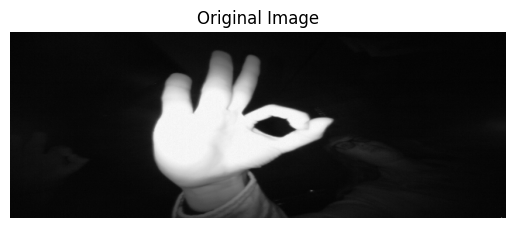

In [16]:
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()